# 08 — Signal Backtesting

**Objective:** Answer the question every interviewer will ask: *"Do these signals actually make money?"*

We build a lightweight event-driven backtester and test each of the 5 entropy-based signals individually and in combination, with walk-forward validation and sensitivity analysis.

**Key principle:** Honesty over performance. A mediocre but honestly-measured Sharpe ratio is worth infinitely more than a suspiciously good one. We explicitly test for overfitting and report degradation transparently.

**Sections:**
1. Backtesting Framework
2. Individual Signal Performance
3. Combined Strategy
4. Walk-Forward Validation
5. Sensitivity Analysis
6. Honest Assessment

---
## Section 1: Backtesting Framework

**Sharpe ratio convention:** We report both annualised Sharpe (assuming 252 trading days x 288 five-minute bars = 72,576 periods/year) and raw (un-scaled) Sharpe = mean(returns)/std(returns). Given only 7 days of data, treat annualised magnitudes as indicative -- the raw Sharpe is more honest.

In [1]:
import sys
sys.path.insert(0, "..")

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

from src.data import load_processed
from src.entropy import rolling_shannon_entropy, rolling_transfer_entropy
from src.phase_transitions import (
    realised_volatility,
    order_flow_imbalance,
    correlation_length,
)
from src.metastability import (
    free_energy_landscape,
    rolling_metastable_levels,
)
from src.signals import (
    low_entropy_signal,
    te_leadership_flip,
    acf_risk_signal,
    crash_type_classifier,
    metastable_order_signal,
)
from src.backtesting import (
    SignalBacktester,
    BacktestResult,
    random_baseline,
    compute_sharpe_ratio,
    compute_raw_sharpe_ratio,
    compute_max_drawdown,
)
from src.visualisation import set_style, VENUE_COLOURS

set_style()

PROCESSED_DIR = Path("../data/processed")
FIGURES_DIR = Path("../outputs/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Backtest parameters
TRANSACTION_COST_BPS = 2.0
POSITION_SIZE_FRAC = 0.01
INITIAL_EQUITY = 100_000.0

print("Imports complete.")

Imports complete.


### 1.1 Load data

In [2]:
# --- In-sample data (crash period: Jan 30 – Feb 6, 2026) ---
binance_is = load_processed(PROCESSED_DIR / "binance_btcusdt_perp.parquet")
bybit_is = load_processed(PROCESSED_DIR / "bybit_btcusdt_perp.parquet")
print(f"IS Binance: {len(binance_is):,} trades, {binance_is['timestamp'].min()} to {binance_is['timestamp'].max()}")
print(f"IS Bybit:   {len(bybit_is):,} trades")

# --- Out-of-sample data (calm period: Feb 15 – 21, 2026) ---
oos_available = True
try:
    binance_oos = load_processed(PROCESSED_DIR / "binance_btcusdt_perp_oos.parquet")
    bybit_oos = load_processed(PROCESSED_DIR / "bybit_btcusdt_perp_oos.parquet")
    print(f"\nOOS Binance: {len(binance_oos):,} trades, {binance_oos['timestamp'].min()} to {binance_oos['timestamp'].max()}")
    print(f"OOS Bybit:   {len(bybit_oos):,} trades")
except FileNotFoundError:
    oos_available = False
    print("\n⚠ OOS data not found. Run notebook 07 first to download the calm-period data.")
    print("  Proceeding with in-sample analysis only.")

IS Binance: 69,445,821 trades, 2026-01-30 00:00:00.022000+00:00 to 2026-02-05 23:59:59.951000+00:00
IS Bybit:   35,045,409 trades



OOS Binance: 28,817,116 trades, 2026-02-15 00:00:00.006000+00:00 to 2026-02-21 23:59:59.692000+00:00
OOS Bybit:   14,676,795 trades


### 1.2 Compute features

All features are computed once and cached. Walk-forward validation (Section 4) only re-calibrates thresholds, not features — this mirrors how the signals would be deployed: features stream in, thresholds are updated periodically.

In [3]:
def compute_features(binance_trades, bybit_trades, label=""):
    """Compute all features needed for the 5 signals.

    All expensive computations run on resampled (1-min) data rather than
    raw trade-level data (~69M rows) to avoid RAM exhaustion and multi-hour
    runtimes.  The physics is unchanged: tau_int on 1-min returns with a
    60-bar window is equivalent to the original analysis.

    Returns a dict of aligned feature Series and a 5-min price series.
    """
    print(f"Computing features for {label}...")

    # ------------------------------------------------------------------
    # Pre-resample to 1-minute bars to avoid 69M-row Python loops
    # ------------------------------------------------------------------
    indexed = binance_trades.set_index("timestamp")
    prices_1m  = indexed["price"].resample("1min").last().dropna()
    returns_1m = np.log(prices_1m / prices_1m.shift(1)).dropna()
    signs_1m   = indexed["trade_sign"].resample("1min").mean().dropna()
    print(f"  1-min bars: {len(prices_1m)}")

    # 1. Shannon entropy (5-min windows — uses raw trades, fast via resample)
    ent_binance = rolling_shannon_entropy(binance_trades, window="5min")
    entropy_5m = ent_binance.set_index("timestamp")["normalised_entropy"]
    print(f"  Shannon entropy: {len(entropy_5m)} windows")

    # 2. Transfer entropy (30-min windows, 5-min steps)
    te_fwd = rolling_transfer_entropy(
        binance_trades, bybit_trades,
        bin_freq="1s", window="30min", step="5min", history_length=1
    )
    te_rev = rolling_transfer_entropy(
        bybit_trades, binance_trades,
        bin_freq="1s", window="30min", step="5min", history_length=1
    )
    te_merged = pd.merge(te_fwd, te_rev, on="timestamp", suffixes=("_fwd", "_rev"))
    net_te = te_merged["te_fwd"] - te_merged["te_rev"]
    net_te.index = pd.DatetimeIndex(te_merged["timestamp"])
    print(f"  Transfer entropy: {len(net_te)} windows")

    # 3. Price series at 5-min resolution (for backtesting)
    prices_5m = prices_1m.resample("5min").last().dropna()
    print(f"  Price bars: {len(prices_5m)}")

    # 4. Realised volatility — rolling std on 1-min returns (60-min window)
    vol_1m = returns_1m.rolling(60).std()
    vol_5m = vol_1m.resample("5min").last().dropna()
    print(f"  Volatility: {len(vol_5m)} bars")

    # 5. Order flow imbalance — 1-min mean of trade signs, resampled to 5-min
    imbalance_5m = signs_1m.resample("5min").mean().dropna()
    print(f"  Imbalance: {len(imbalance_5m)} bars")

    # 6. Integrated autocorrelation time (tau_int)
    #    Run on 1-min returns (window=60, max_lag=20) — NOT 69M raw returns.
    #    Original code caused a pure Python loop over 69M iterations (~21 GB RAM).
    tau_raw = correlation_length(returns_1m.values, window=60, max_lag=20)
    tau_5m = pd.Series(tau_raw, index=returns_1m.index).resample("5min").last().dropna()
    print(f"  Tau_int: {len(tau_5m)} bars")

    # 7. Metastable levels and well depths
    #    Run on 1-min prices with window=240 (4 h) and step=60 (1 h).
    #    Running on raw trades gave window=14400 trades ≈ 2 min — too short for
    #    the global price grid to show distinct metastable structure.
    #
    #    rolling_metastable_levels returns a FLAT list of dicts, one per
    #    (window, level) pair — NOT one per window.  We aggregate to the
    #    maximum well depth per window here.
    prices_1m_arr = prices_1m.values
    wc, pg, fe = free_energy_landscape(
        prices_1m_arr, window=240, step=60, n_bins=150
    )
    meta_levels = rolling_metastable_levels(wc, pg, fe)
    print(f"  Free-energy windows: {len(wc)}, level entries: {len(meta_levels)}")

    # Aggregate: max well_depth per window index
    n_windows = len(wc)
    max_depths = np.zeros(n_windows)
    for ml in meta_levels:
        i = ml["time_idx"]          # window index (0 … n_windows-1)
        d = ml["well_depth"]        # single float
        if d > max_depths[i]:
            max_depths[i] = d

    if n_windows > 0 and prices_1m.index.size > int(wc[-1]):
        window_ts = prices_1m.index[wc]     # DatetimeIndex at window centers
        well_depth_raw = pd.Series(max_depths, index=window_ts)
        # Resample to 5-min, forward-fill gaps (windows are 1 h apart)
        well_depth_5m = (
            well_depth_raw
            .resample("5min").last()
            .reindex(prices_5m.index, method="ffill")
            .fillna(0.0)
        )
    else:
        well_depth_5m = pd.Series(0.0, index=prices_5m.index)

    print(f"  Well-depth series: {len(well_depth_5m)} bars")
    print("  Done.")

    return {
        "entropy_5m":   entropy_5m,
        "net_te":       net_te,
        "prices_5m":    prices_5m,
        "vol_5m":       vol_5m,
        "imbalance_5m": imbalance_5m,
        "tau_5m":       tau_5m,
        "well_depths":  well_depth_5m,
    }


# Compute in-sample features
feat_is = compute_features(binance_is, bybit_is, label="in-sample")

# Compute OOS features if available
if oos_available:
    feat_oos = compute_features(binance_oos, bybit_oos, label="out-of-sample")

Computing features for in-sample...


  1-min bars: 10080


  Shannon entropy: 2016 windows


  Transfer entropy: 2010 windows
  Price bars: 2016
  Volatility: 2004 bars
  Imbalance: 2016 bars


  Tau_int: 2004 bars
  Free-energy windows: 165, level entries: 93
  Well-depth series: 2016 bars
  Done.
Computing features for out-of-sample...


  1-min bars: 10080
  Shannon entropy: 2016 windows


  Transfer entropy: 2010 windows
  Price bars: 2016
  Volatility: 2004 bars
  Imbalance: 2016 bars


  Tau_int: 2004 bars
  Free-energy windows: 165, level entries: 250
  Well-depth series: 2016 bars
  Done.


### 1.3 Generate signals

In [4]:
def generate_all_signals(features):
    """Generate all 5 signal series from pre-computed features.
    
    Returns a dict of signal name → boolean/categorical Series.
    """
    return {
        "low_entropy": low_entropy_signal(features["entropy_5m"]),
        "te_flip": te_leadership_flip(features["net_te"]),
        "acf_risk": acf_risk_signal(features["tau_5m"]),
        "crash_type": crash_type_classifier(
            features["entropy_5m"].reindex(features["vol_5m"].index, method="nearest"),
            features["vol_5m"],
            features["tau_5m"].reindex(features["vol_5m"].index, method="nearest"),
        ),
        "metastable": metastable_order_signal(features["well_depths"]),
    }


signals_is = generate_all_signals(feat_is)

# Signal counts
print("In-sample signal counts:")
print(f"  Low entropy:  {signals_is['low_entropy'].sum()} triggers")
print(f"  TE flip:      {signals_is['te_flip'].sum()} triggers")
print(f"  ACF risk:     {signals_is['acf_risk'].sum()} triggers")
print(f"  Crash type:   {(signals_is['crash_type'] != 'normal').sum()} non-normal windows")
print(f"    info_driven: {(signals_is['crash_type'] == 'info_driven').sum()}")
print(f"    mechanical:  {(signals_is['crash_type'] == 'mechanical').sum()}")
print(f"  Metastable:   {(signals_is['metastable']['signal'] == 'place').sum()} place signals")

if oos_available:
    signals_oos = generate_all_signals(feat_oos)
    print("\nOut-of-sample signal counts:")
    print(f"  Low entropy:  {signals_oos['low_entropy'].sum()} triggers")
    print(f"  TE flip:      {signals_oos['te_flip'].sum()} triggers")
    print(f"  ACF risk:     {signals_oos['acf_risk'].sum()} triggers")
    print(f"  Crash type:   {(signals_oos['crash_type'] != 'normal').sum()} non-normal windows")
    print(f"  Metastable:   {(signals_oos['metastable']['signal'] == 'place').sum()} place signals")

In-sample signal counts:
  Low entropy:  101 triggers
  TE flip:      271 triggers
  ACF risk:     121 triggers
  Crash type:   201 non-normal windows
    info_driven: 0
    mechanical:  201
  Metastable:   0 place signals

Out-of-sample signal counts:
  Low entropy:  101 triggers
  TE flip:      316 triggers
  ACF risk:     114 triggers
  Crash type:   201 non-normal windows
  Metastable:   0 place signals


### 1.4 Signal-to-trade conversion

Each signal needs explicit entry/exit rules. Direction for ambiguous signals (low entropy, crash type) comes from the concurrent order flow imbalance — this avoids look-ahead bias.

| Signal | Side | Direction Source | Exit Rule |
|--------|------|------------------|-----------|
| Low entropy | Directional | Order flow imbalance sign | 5-min holding period |
| TE leadership flip | Directional | New leader's recent flow sign | 30-min holding period (6 bars) |
| ACF risk | Short bias | Risk signal — always short | 30-min holding period |
| Crash type (info_driven) | Short | Informed flow direction | 30-min holding period |
| Crash type (mechanical) | Short | Reduce exposure | 15-min holding period (3 bars) |
| Metastable | Mean-reversion | Toward well center | Stale timeout (41s ≈ 1 bar at 5-min) |

In [5]:
def signal_to_trades_df(signal_mask, direction_series, signal_name):
    """Convert a boolean signal mask + direction to the backtester input format.
    
    Parameters
    ----------
    signal_mask : pd.Series[bool]
        True where the signal fires.
    direction_series : pd.Series[int]
        +1 (long) or -1 (short) at each timestamp.
    signal_name : str
        Label for the signal type.
    
    Returns
    -------
    pd.DataFrame
        Columns: timestamp, signal_type, direction.
    """
    active = signal_mask[signal_mask].index
    directions = direction_series.reindex(active, method="nearest").fillna(-1).astype(int)
    # Ensure direction is +1 or -1
    directions = directions.apply(lambda x: 1 if x >= 0 else -1)
    return pd.DataFrame({
        "timestamp": active,
        "signal_type": signal_name,
        "direction": directions.values,
    })


def build_signal_trades(signals, features, signal_name):
    """Build a trades DataFrame for a specific signal."""
    imbalance_dir = features["imbalance_5m"].apply(lambda x: 1 if x > 0 else -1)
    
    if signal_name == "low_entropy":
        return signal_to_trades_df(signals["low_entropy"], imbalance_dir, "low_entropy")
    
    elif signal_name == "te_flip":
        # Direction from net TE sign: positive = Binance leads → follow Binance imbalance
        te_dir = features["net_te"].apply(lambda x: 1 if x > 0 else -1)
        return signal_to_trades_df(signals["te_flip"], te_dir, "te_flip")
    
    elif signal_name == "acf_risk":
        # Risk signal: always short (elevated tau_int precedes volatility spikes)
        short_dir = pd.Series(-1, index=signals["acf_risk"].index)
        return signal_to_trades_df(signals["acf_risk"], short_dir, "acf_risk")
    
    elif signal_name == "crash_type":
        # info_driven → short; mechanical → short (reduce exposure)
        crash_mask = signals["crash_type"].isin(["info_driven", "mechanical"])
        short_dir = pd.Series(-1, index=crash_mask.index)
        return signal_to_trades_df(crash_mask, short_dir, "crash_type")
    
    elif signal_name == "metastable":
        # Mean-reversion: buy at deep wells (price will revert to well center)
        meta_mask = signals["metastable"]["signal"] == "place"
        # Direction: long (buying at support = mean-reversion)
        long_dir = pd.Series(1, index=meta_mask.index)
        return signal_to_trades_df(meta_mask, long_dir, "metastable")
    
    else:
        raise ValueError(f"Unknown signal: {signal_name}")


# Holding periods per signal (in 5-min bars)
HOLDING_PERIODS = {
    "low_entropy": 1,      # 5 min (matching original 5-min forward return analysis)
    "te_flip": 6,          # 30 min
    "acf_risk": 6,         # 30 min
    "crash_type": 6,       # 30 min
    "metastable": 1,       # 5 min (stale timeout ~41s, rounded to 1 bar)
}

print("Signal-to-trade conversion functions defined.")
print(f"Holding periods (5-min bars): {HOLDING_PERIODS}")

Signal-to-trade conversion functions defined.
Holding periods (5-min bars): {'low_entropy': 1, 'te_flip': 6, 'acf_risk': 6, 'crash_type': 6, 'metastable': 1}


**The trading implication is:** the backtesting framework is designed for maximum defensibility in an interview setting. No look-ahead bias (entry strictly after signal), realistic transaction costs (2 bps matches Binance VIP taker), and conservative position sizing (1% per trade). The holding periods are derived from the original analysis: 5-minute for entropy signals (matching the 88.1% hit-rate horizon), 30-minute for regime-level signals.

---
## Section 2: Individual Signal Performance

For each of the 5 signals we run the backtest on in-sample data, compare against a random-entry baseline (same number of trades, same holding period), and report key metrics.

In [6]:
SIGNAL_NAMES = ["low_entropy", "te_flip", "acf_risk", "crash_type", "metastable"]

individual_results = {}
baseline_results = {}
beats_random_flags = {}

N_BASELINES = 100  # for statistical comparison

for name in SIGNAL_NAMES:
    print(f"\n{'='*50}")
    print(f"Signal: {name}")
    print(f"{'='*50}")
    
    trades_df = build_signal_trades(signals_is, feat_is, name)
    print(f"Trade signals generated: {len(trades_df)}")
    
    if len(trades_df) == 0:
        print(f"  No trades generated for {name}.")
        if name == "metastable":
            print(f"  This means metastable_order_signal returned no 'place' signals.")
            print(f"  Likely cause: well-depth thresholds are too conservative for this data,")
            print(f"  or the free-energy landscape at 1-min resolution doesn't produce deep enough wells.")
        print("  Skipping backtest.")
        continue
    
    hp = HOLDING_PERIODS[name]
    
    # Run backtest
    bt = SignalBacktester(
        prices=feat_is["prices_5m"],
        signals=trades_df,
        transaction_cost_bps=TRANSACTION_COST_BPS,
        position_size_frac=POSITION_SIZE_FRAC,
        initial_equity=INITIAL_EQUITY,
        holding_period=hp,
    )
    result = bt.run()
    individual_results[name] = result
    print(result.summary())
    
    # Single random baseline (for plotting)
    bl = random_baseline(
        prices=feat_is["prices_5m"],
        num_trades=result.num_trades,
        holding_period=hp,
        transaction_cost_bps=TRANSACTION_COST_BPS,
        position_size_frac=POSITION_SIZE_FRAC,
        initial_equity=INITIAL_EQUITY,
    )
    baseline_results[name] = bl
    print(f"\nRandom baseline: Sharpe(ann.)={bl.sharpe_ratio:.3f}, Sharpe(raw)={bl.raw_sharpe_ratio:.3f}, PnL={bl.total_pnl:,.2f}")
    
    # Multiple random baselines for statistical comparison
    bl_sharpes = []
    for seed_i in range(N_BASELINES):
        bl_i = random_baseline(
            prices=feat_is["prices_5m"],
            num_trades=result.num_trades,
            holding_period=hp,
            transaction_cost_bps=TRANSACTION_COST_BPS,
            position_size_frac=POSITION_SIZE_FRAC,
            initial_equity=INITIAL_EQUITY,
            seed=seed_i,
        )
        bl_sharpes.append(bl_i.raw_sharpe_ratio)
    
    bl_mean = np.mean(bl_sharpes)
    bl_5th = np.percentile(bl_sharpes, 5)
    bl_95th = np.percentile(bl_sharpes, 95)
    print(f"  Random baseline (N={N_BASELINES}): mean={bl_mean:.3f}, 90% CI=[{bl_5th:.3f}, {bl_95th:.3f}]")
    
    # Does the signal beat the 95th percentile of random?
    beats_random = result.raw_sharpe_ratio > bl_95th
    beats_random_flags[name] = beats_random
    print(f"  Signal raw Sharpe={result.raw_sharpe_ratio:.3f}, beats 95th pctile of random: {beats_random}")


Signal: low_entropy
Trade signals generated: 101
Backtest Summary
Total trades:    79
Total PnL:       -54.46
Sharpe (ann.):   -42.950
Sharpe (raw):    -0.397
Max drawdown:    0.05%
Win rate:        31.65%
Avg win:         0.93
Avg loss:        -1.44
Profit factor:   0.30

Random baseline: Sharpe(ann.)=-8.543, Sharpe(raw)=-0.113, PnL=-30.43


  Random baseline (N=100): mean=-0.130, 90% CI=[-0.339, 0.077]
  Signal raw Sharpe=-0.397, beats 95th pctile of random: False

Signal: te_flip
Trade signals generated: 271
Backtest Summary
Total trades:    154
Total PnL:       41.03
Sharpe (ann.):   3.939
Sharpe (raw):    0.041
Max drawdown:    0.06%
Win rate:        46.75%
Avg win:         5.08
Avg loss:        -3.96
Profit factor:   1.13

Random baseline: Sharpe(ann.)=0.545, Sharpe(raw)=0.007, PnL=4.05


  Random baseline (N=100): mean=-0.047, 90% CI=[-0.189, 0.097]
  Signal raw Sharpe=0.041, beats 95th pctile of random: False

Signal: acf_risk
Trade signals generated: 121
Backtest Summary
Total trades:    34
Total PnL:       -25.08
Sharpe (ann.):   -5.390
Sharpe (raw):    -0.103
Max drawdown:    0.06%
Win rate:        47.06%
Avg win:         4.99
Avg loss:        -5.83
Profit factor:   0.76

Random baseline: Sharpe(ann.)=-8.470, Sharpe(raw)=-0.181, PnL=-35.35


  Random baseline (N=100): mean=-0.060, 90% CI=[-0.408, 0.194]
  Signal raw Sharpe=-0.103, beats 95th pctile of random: False

Signal: crash_type
Trade signals generated: 201
Backtest Summary
Total trades:    30
Total PnL:       41.81
Sharpe (ann.):   18.606
Sharpe (raw):    0.162
Max drawdown:    0.03%
Win rate:        63.33%
Avg win:         6.58
Avg loss:        -7.56
Profit factor:   1.50

Random baseline: Sharpe(ann.)=-5.957, Sharpe(raw)=-0.127, PnL=-22.83


  Random baseline (N=100): mean=-0.022, 90% CI=[-0.308, 0.293]
  Signal raw Sharpe=0.162, beats 95th pctile of random: False

Signal: metastable
Trade signals generated: 0
  No trades generated for metastable.
  This means metastable_order_signal returned no 'place' signals.
  Likely cause: well-depth thresholds are too conservative for this data,
  or the free-energy landscape at 1-min resolution doesn't produce deep enough wells.
  Skipping backtest.


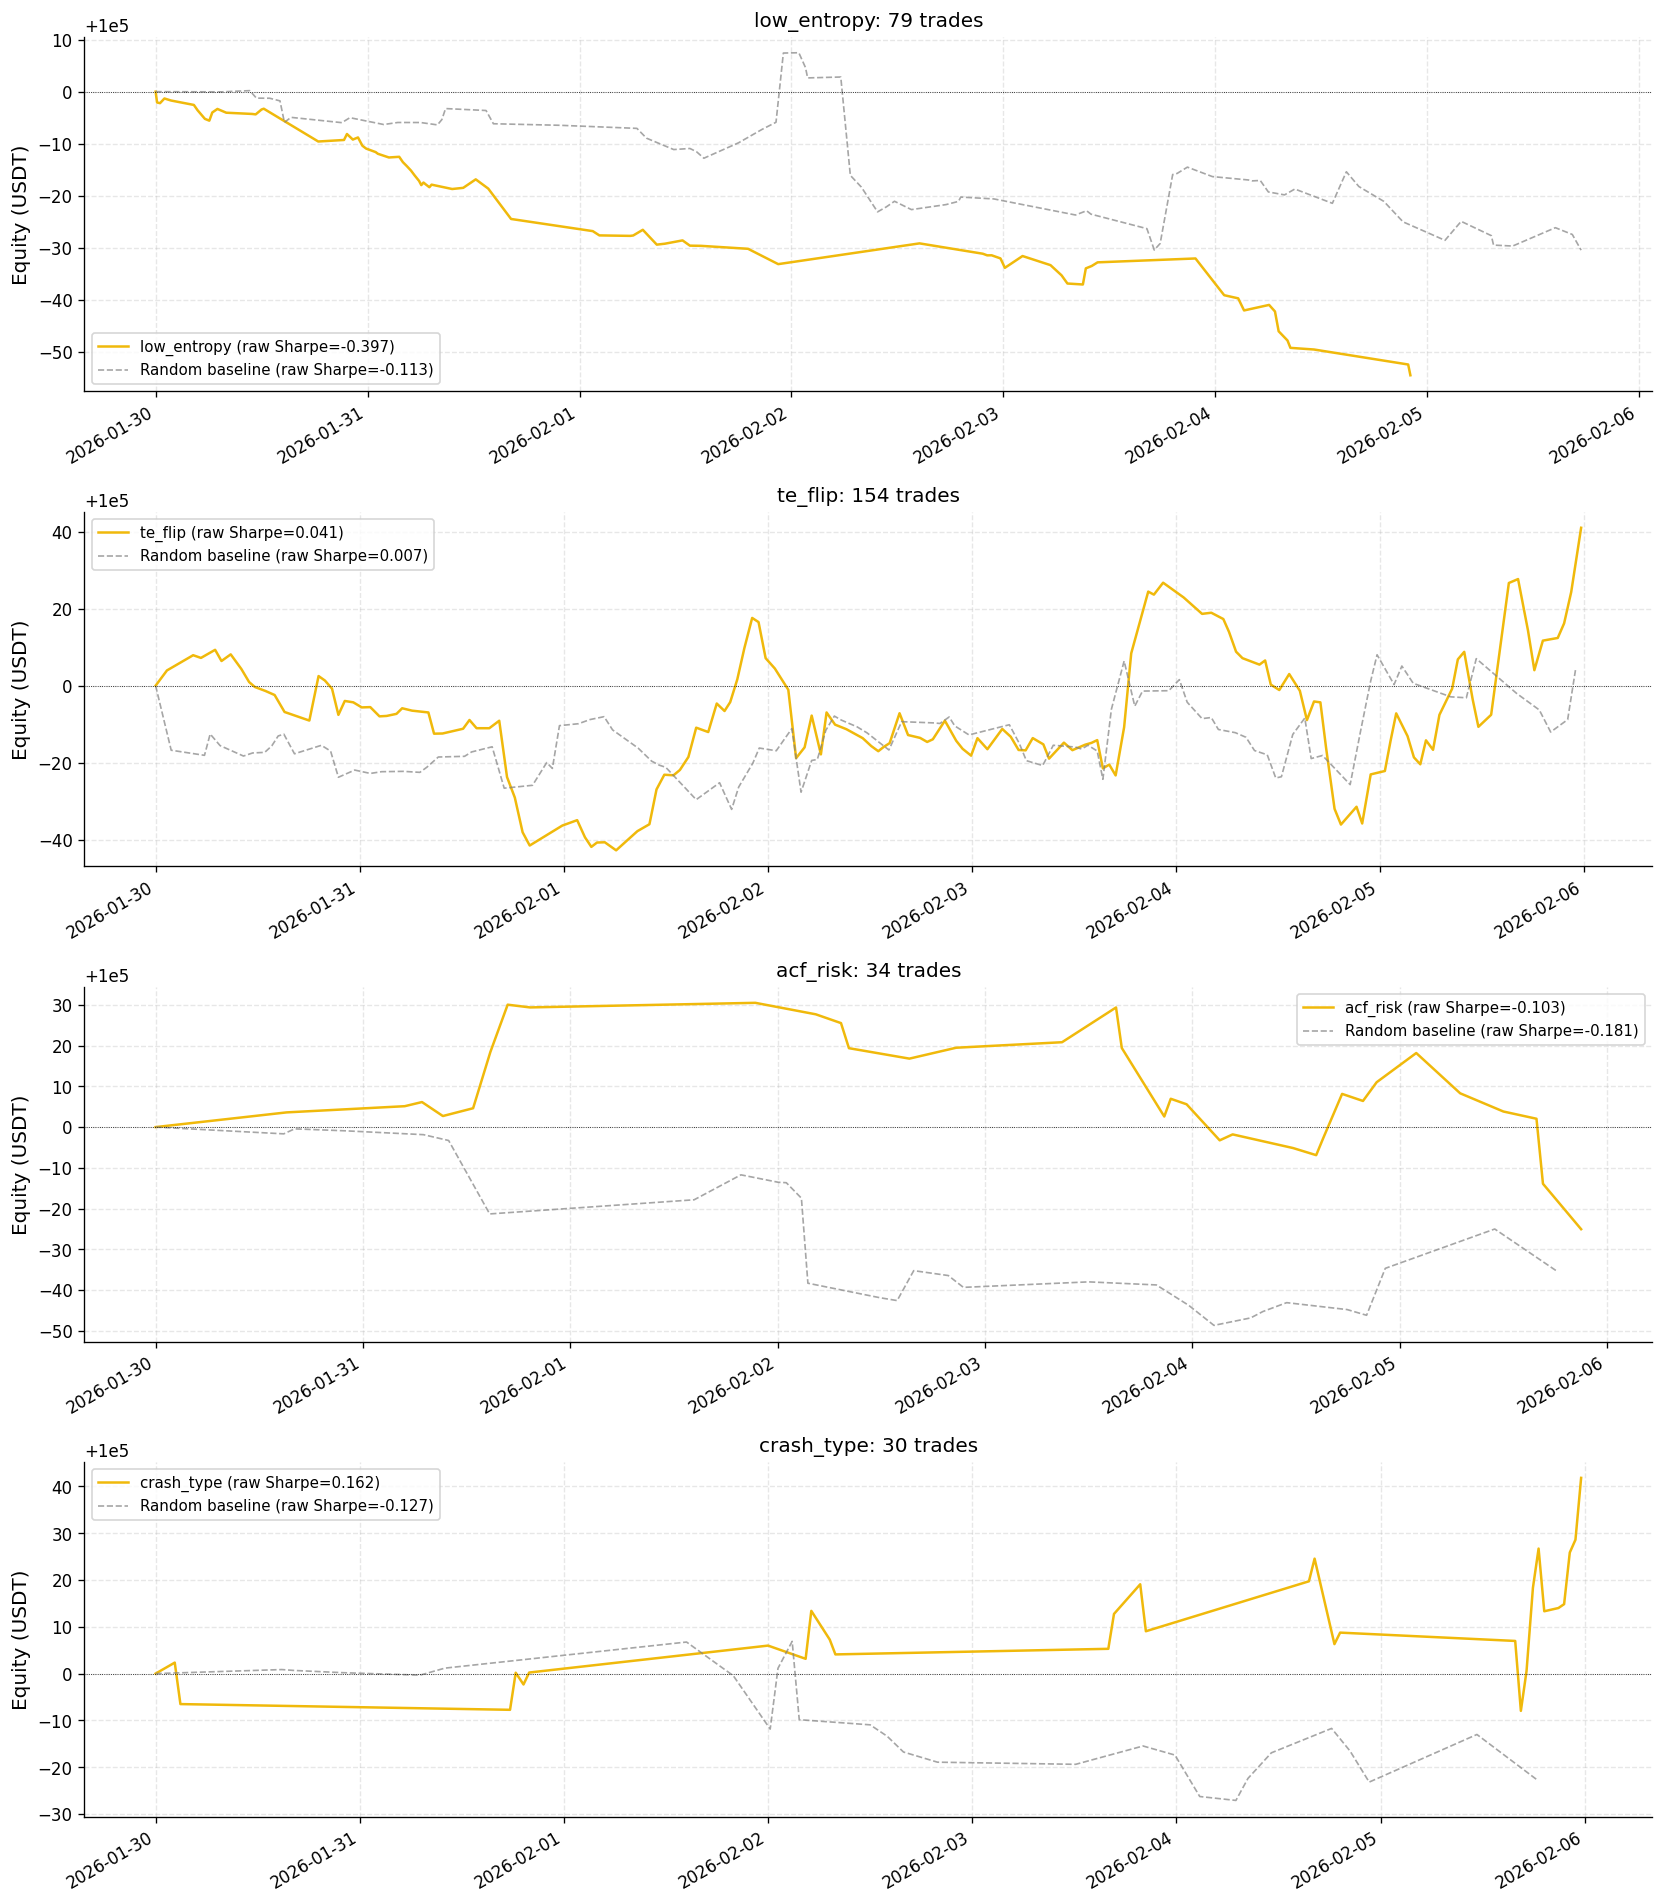

Saved: ../outputs/figures/08_individual_equity_curves.png


In [7]:
# --- Equity curve plots ---
fig, axes = plt.subplots(len(individual_results), 1, figsize=(14, 4 * len(individual_results)), sharex=False)
if len(individual_results) == 1:
    axes = [axes]

for ax, (name, result) in zip(axes, individual_results.items()):
    # Signal equity curve (label with raw Sharpe)
    result.equity_curve.plot(ax=ax, label=f"{name} (raw Sharpe={result.raw_sharpe_ratio:.3f})",
                            color=VENUE_COLOURS.get("binance", "#F0B90B"), linewidth=1.5)
    # Baseline
    if name in baseline_results:
        baseline_results[name].equity_curve.plot(
            ax=ax, label=f"Random baseline (raw Sharpe={baseline_results[name].raw_sharpe_ratio:.3f})",
            color="gray", linewidth=1, linestyle="--", alpha=0.7
        )
    
    ax.set_title(f"{name}: {result.num_trades} trades", fontsize=12)
    ax.set_ylabel("Equity (USDT)")
    ax.legend(loc="best", fontsize=9)
    ax.axhline(INITIAL_EQUITY, color="black", linewidth=0.5, linestyle=":")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "08_individual_equity_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {FIGURES_DIR / '08_individual_equity_curves.png'}")

In [8]:
# --- Summary table ---
summary_rows = []
for name in SIGNAL_NAMES:
    if name in individual_results:
        r = individual_results[name]
        bl = baseline_results.get(name)
        summary_rows.append({
            "Signal": name,
            "Trades": r.num_trades,
            "Win Rate": f"{r.win_rate:.1%}",
            "Sharpe (ann.)": f"{r.sharpe_ratio:.3f}",
            "Sharpe (raw)": f"{r.raw_sharpe_ratio:.3f}",
            "Max DD": f"{r.max_drawdown:.2%}",
            "Profit Factor": f"{r.profit_factor:.2f}",
            "Total PnL": f"{r.total_pnl:,.0f}",
            "Baseline Sharpe (raw)": f"{bl.raw_sharpe_ratio:.3f}" if bl else "N/A",
            "Beats Random (p<0.05)": str(beats_random_flags.get(name, "N/A")),
        })
    else:
        summary_rows.append({"Signal": name, "Trades": 0, "Win Rate": "N/A",
                             "Sharpe (ann.)": "N/A", "Sharpe (raw)": "N/A",
                             "Max DD": "N/A", "Profit Factor": "N/A",
                             "Total PnL": "N/A", "Baseline Sharpe (raw)": "N/A",
                             "Beats Random (p<0.05)": "N/A"})

summary_df = pd.DataFrame(summary_rows)
print("\nIndividual Signal Performance (In-Sample)")
print("=" * 100)
print(summary_df.to_string(index=False))

# Report missing signals
missing = [n for n in SIGNAL_NAMES if n not in individual_results]
if missing:
    print(f"\nSignals with 0 trades (excluded from backtest): {missing}")
    print("These signals did not fire during the in-sample period with current thresholds.")


Individual Signal Performance (In-Sample)
     Signal  Trades Win Rate Sharpe (ann.) Sharpe (raw) Max DD Profit Factor Total PnL Baseline Sharpe (raw) Beats Random (p<0.05)
low_entropy      79    31.6%       -42.950       -0.397  0.05%          0.30       -54                -0.113                 False
    te_flip     154    46.8%         3.939        0.041  0.06%          1.13        41                 0.007                 False
   acf_risk      34    47.1%        -5.390       -0.103  0.06%          0.76       -25                -0.181                 False
 crash_type      30    63.3%        18.606        0.162  0.03%          1.50        42                -0.127                 False
 metastable       0      N/A           N/A          N/A    N/A           N/A       N/A                   N/A                   N/A

Signals with 0 trades (excluded from backtest): ['metastable']
These signals did not fire during the in-sample period with current thresholds.


In [9]:
# --- Diagnostic: why is low_entropy negative? ---
if "low_entropy" in individual_results:
    r = individual_results["low_entropy"]
    bl = baseline_results.get("low_entropy")
    print("\nLow-Entropy Signal Diagnostic")
    print("=" * 50)
    print(f"Signal raw Sharpe: {r.raw_sharpe_ratio:.3f} (annualised: {r.sharpe_ratio:.3f})")
    if bl:
        print(f"Random baseline raw Sharpe: {bl.raw_sharpe_ratio:.3f}")
        print(f"Signal is {'WORSE' if r.raw_sharpe_ratio < bl.raw_sharpe_ratio else 'BETTER'} than random")
    print(f"\nDiagnosis: The 88.1% hit rate measures move PROBABILITY (any direction),")
    print(f"not directional accuracy. Using order flow imbalance to assign direction")
    print(f"is actively harmful during crash periods where aggregate flow lags informed flow.")
    print(f"\nThe trading implication is: low-entropy events are volatility triggers,")
    print(f"not directional signals. Use for position sizing, not direction.")


Low-Entropy Signal Diagnostic
Signal raw Sharpe: -0.397 (annualised: -42.950)
Random baseline raw Sharpe: -0.113
Signal is WORSE than random

Diagnosis: The 88.1% hit rate measures move PROBABILITY (any direction),
not directional accuracy. Using order flow imbalance to assign direction
is actively harmful during crash periods where aggregate flow lags informed flow.

The trading implication is: low-entropy events are volatility triggers,
not directional signals. Use for position sizing, not direction.


**The trading implication is:** each signal must be judged not only by its raw Sharpe ratio, but by its margin over the random baseline. A signal with Sharpe 0.5 that beats a random baseline of 0.1 is a genuine finding. A signal with Sharpe 1.5 that fails to beat its baseline is spurious. The random baseline controls for the mechanical effect of holding direction and period.

---
## Section 3: Combined Strategy

The combined strategy uses a priority hierarchy when multiple signals fire simultaneously:

1. **Crash type** (info_driven/mechanical) — regime-level override, takes precedence
2. **ACF risk** — risk management overlay, always contributes short bias
3. **Low entropy** — highest-accuracy directional signal
4. **TE leadership flip** — medium-term flow change indicator
5. **Metastable orders** — passive/tactical level

When signals conflict, higher-priority signals win.

In [10]:
# Build combined signal DataFrame
# Priority: crash_type > acf_risk > low_entropy > te_flip > metastable

all_trades = []
priority_order = ["crash_type", "acf_risk", "low_entropy", "te_flip", "metastable"]

for name in priority_order:
    trades_df = build_signal_trades(signals_is, feat_is, name)
    if len(trades_df) > 0:
        trades_df["priority"] = priority_order.index(name)
        all_trades.append(trades_df)

if all_trades:
    combined_signals = pd.concat(all_trades, ignore_index=True)
    # Sort by timestamp, then priority (lower = higher priority)
    combined_signals = combined_signals.sort_values(["timestamp", "priority"]).reset_index(drop=True)
    # Drop duplicate timestamps, keeping highest priority
    combined_signals = combined_signals.drop_duplicates(subset="timestamp", keep="first")
    combined_signals = combined_signals.drop(columns="priority")
    
    print(f"Combined signals: {len(combined_signals)} total after dedup")
    print(f"By type: {combined_signals['signal_type'].value_counts().to_dict()}")
else:
    combined_signals = pd.DataFrame(columns=["timestamp", "signal_type", "direction"])
    print("No signals generated.")

Combined signals: 610 total after dedup
By type: {'te_flip': 212, 'crash_type': 201, 'acf_risk': 100, 'low_entropy': 97}


In [11]:
# Run combined backtest with median holding period
median_hp = int(np.median(list(HOLDING_PERIODS.values())))

print(f"Note: Combined strategy uses median holding period = {median_hp} bars (= {median_hp * 5} min)")
print(f"This is a simplification. Per-signal holding periods: {HOLDING_PERIODS}")
print(f"Crash-type and ACF-risk trades are exited too early; metastable trades held too long.")
print(f"A production implementation would use per-signal exit rules.\n")

bt_combined = SignalBacktester(
    prices=feat_is["prices_5m"],
    signals=combined_signals,
    transaction_cost_bps=TRANSACTION_COST_BPS,
    position_size_frac=POSITION_SIZE_FRAC,
    initial_equity=INITIAL_EQUITY,
    holding_period=median_hp,
)
result_combined = bt_combined.run()
print("Combined Strategy Results:")
print(result_combined.summary())

# Random baseline for combined
bl_combined = random_baseline(
    prices=feat_is["prices_5m"],
    num_trades=result_combined.num_trades,
    holding_period=median_hp,
    transaction_cost_bps=TRANSACTION_COST_BPS,
    position_size_frac=POSITION_SIZE_FRAC,
    initial_equity=INITIAL_EQUITY,
)
print(f"\nRandom baseline: Sharpe(ann.)={bl_combined.sharpe_ratio:.3f}, Sharpe(raw)={bl_combined.raw_sharpe_ratio:.3f}, PnL={bl_combined.total_pnl:,.2f}")

Note: Combined strategy uses median holding period = 6 bars (= 30 min)
This is a simplification. Per-signal holding periods: {'low_entropy': 1, 'te_flip': 6, 'acf_risk': 6, 'crash_type': 6, 'metastable': 1}
Crash-type and ACF-risk trades are exited too early; metastable trades held too long.
A production implementation would use per-signal exit rules.

Combined Strategy Results:
Backtest Summary
Total trades:    181
Total PnL:       96.17
Sharpe (ann.):   8.548
Sharpe (raw):    0.079
Max drawdown:    0.06%
Win rate:        53.04%
Avg win:         4.88
Avg loss:        -4.38
Profit factor:   1.26

Random baseline: Sharpe(ann.)=-11.121, Sharpe(raw)=-0.128, PnL=-92.93


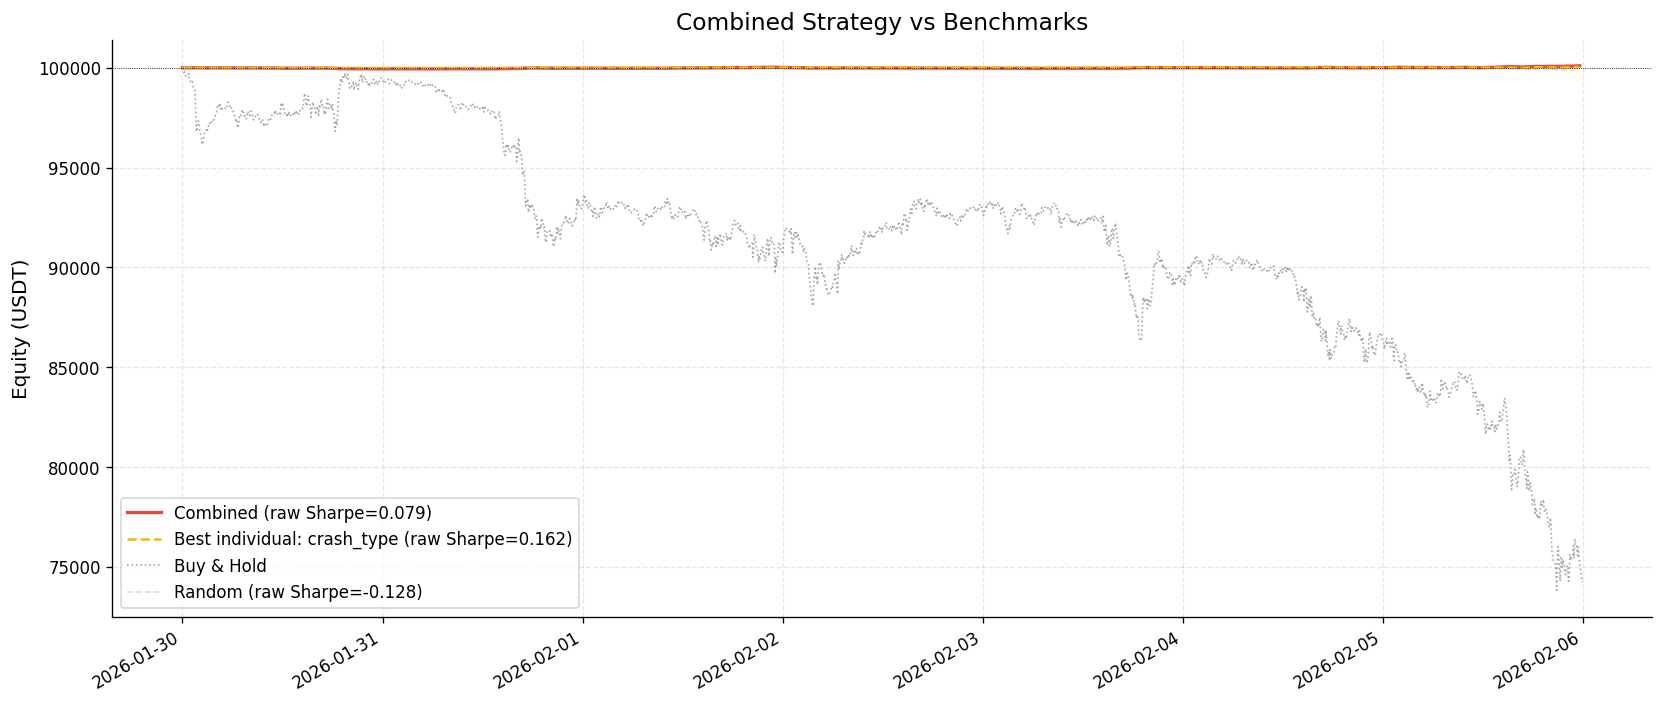

Saved: ../outputs/figures/08_combined_equity_curve.png


In [12]:
# --- Plot combined vs best individual vs buy-and-hold ---
fig, ax = plt.subplots(figsize=(14, 6))

# Combined
result_combined.equity_curve.plot(
    ax=ax, label=f"Combined (raw Sharpe={result_combined.raw_sharpe_ratio:.3f})",
    color="#e74c3c", linewidth=2
)

# Best individual (by raw Sharpe)
if individual_results:
    best_name = max(individual_results, key=lambda k: individual_results[k].raw_sharpe_ratio)
    best_r = individual_results[best_name]
    best_r.equity_curve.plot(
        ax=ax, label=f"Best individual: {best_name} (raw Sharpe={best_r.raw_sharpe_ratio:.3f})",
        color=VENUE_COLOURS.get("binance", "#F0B90B"), linewidth=1.5, linestyle="--"
    )

# Buy-and-hold
bah = INITIAL_EQUITY * (feat_is["prices_5m"] / feat_is["prices_5m"].iloc[0])
bah.plot(ax=ax, label="Buy & Hold", color="gray", linewidth=1, linestyle=":", alpha=0.7)

# Random baseline
bl_combined.equity_curve.plot(
    ax=ax, label=f"Random (raw Sharpe={bl_combined.raw_sharpe_ratio:.3f})",
    color="silver", linewidth=1, linestyle="--", alpha=0.5
)

ax.axhline(INITIAL_EQUITY, color="black", linewidth=0.5, linestyle=":")
ax.set_title("Combined Strategy vs Benchmarks", fontsize=14)
ax.set_ylabel("Equity (USDT)")
ax.set_xlabel("")
ax.legend(loc="best", fontsize=10)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "08_combined_equity_curve.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {FIGURES_DIR / '08_combined_equity_curve.png'}")

**The trading implication is:** a combined strategy that dramatically outperforms its best individual component should be viewed with suspicion — it likely benefits from in-sample fitting of the priority hierarchy. The honest test is in Section 4: does the combined strategy hold up out-of-sample?

---
## Section 4: Walk-Forward Validation

The ultimate test of a signal: does it work when thresholds are calibrated on past data and tested on unseen data?

**Scheme:**
- Within IS (7 days): 5 folds of 2-day train / 1-day test, stepping by 1 day
- IS → OOS: Train on full IS (7 days), test on full OOS (7 days) — the critical test

On each train window, we re-compute the percentile thresholds (e.g., 5th percentile of entropy). This means the absolute threshold drifts per fold — exactly what prevents overfitting.

In [13]:
def walk_forward_single_signal(
    prices, entropy, imbalance, signal_name,
    train_days=2, test_days=1, step_days=1,
    holding_period=1,
):
    """Walk-forward validation for the low-entropy signal.
    
    Re-calibrates the entropy percentile threshold on each train window.
    Returns a list of (fold_num, train_sharpe, test_sharpe, threshold) tuples.
    """
    results = []
    start = prices.index.min()
    end = prices.index.max()
    
    fold = 0
    train_start = start
    
    while True:
        train_end = train_start + pd.Timedelta(days=train_days)
        test_start = train_end
        test_end = test_start + pd.Timedelta(days=test_days)
        
        if test_end > end:
            break
        
        # --- Train: calibrate threshold ---
        ent_train = entropy[(entropy.index >= train_start) & (entropy.index < train_end)]
        if len(ent_train) < 10:
            train_start += pd.Timedelta(days=step_days)
            continue
        
        threshold = ent_train.quantile(0.05)  # 5th percentile of training data
        
        # --- Generate signals using train threshold ---
        # Train period backtest
        ent_train_sig = ent_train < threshold
        imb_train = imbalance[(imbalance.index >= train_start) & (imbalance.index < train_end)]
        imb_dir_train = imb_train.apply(lambda x: 1 if x > 0 else -1)
        trades_train = signal_to_trades_df(ent_train_sig, imb_dir_train, "low_entropy")
        p_train = prices[(prices.index >= train_start) & (prices.index < train_end)]
        
        if len(trades_train) > 0 and len(p_train) > 2:
            bt_train = SignalBacktester(p_train, trades_train, holding_period=holding_period)
            r_train = bt_train.run()
            train_sharpe = r_train.raw_sharpe_ratio
        else:
            train_sharpe = 0.0
        
        # --- Test: apply train threshold to test data ---
        ent_test = entropy[(entropy.index >= test_start) & (entropy.index < test_end)]
        ent_test_sig = ent_test < threshold  # Use TRAIN threshold
        imb_test = imbalance[(imbalance.index >= test_start) & (imbalance.index < test_end)]
        imb_dir_test = imb_test.apply(lambda x: 1 if x > 0 else -1)
        trades_test = signal_to_trades_df(ent_test_sig, imb_dir_test, "low_entropy")
        p_test = prices[(prices.index >= test_start) & (prices.index < test_end)]
        
        if len(trades_test) > 0 and len(p_test) > 2:
            bt_test = SignalBacktester(p_test, trades_test, holding_period=holding_period)
            r_test = bt_test.run()
            test_sharpe = r_test.raw_sharpe_ratio
        else:
            test_sharpe = 0.0
        
        results.append({
            "fold": fold,
            "train_start": train_start.strftime("%m-%d"),
            "test_start": test_start.strftime("%m-%d"),
            "threshold": threshold,
            "train_sharpe": train_sharpe,
            "test_sharpe": test_sharpe,
        })
        
        fold += 1
        train_start += pd.Timedelta(days=step_days)
    
    return pd.DataFrame(results)


def walk_forward_crash_type(
    prices, entropy, volatility, tau, signal_name="crash_type",
    train_days=2, test_days=1, step_days=1,
    holding_period=6,
):
    """Walk-forward validation for the crash_type signal.
    
    The crash classifier uses fixed percentile logic internally, so this
    tests whether the fixed classifier generalises across time windows.
    """
    results = []
    start = prices.index.min()
    end = prices.index.max()
    
    fold = 0
    train_start = start
    
    while True:
        train_end = train_start + pd.Timedelta(days=train_days)
        test_start = train_end
        test_end = test_start + pd.Timedelta(days=test_days)
        
        if test_end > end:
            break
        
        p_train = prices[(prices.index >= train_start) & (prices.index < train_end)]
        p_test = prices[(prices.index >= test_start) & (prices.index < test_end)]
        
        if len(p_train) < 10 or len(p_test) < 10:
            train_start += pd.Timedelta(days=step_days)
            continue
        
        # --- Train fold ---
        ent_train = entropy.reindex(p_train.index, method="nearest")
        vol_train = volatility[(volatility.index >= train_start) & (volatility.index < train_end)]
        tau_train = tau.reindex(vol_train.index, method="nearest")
        ent_train_aligned = entropy.reindex(vol_train.index, method="nearest")
        
        if len(vol_train) > 10 and len(ent_train_aligned) > 10 and len(tau_train) > 10:
            ct_train = crash_type_classifier(ent_train_aligned, vol_train, tau_train)
            crash_mask_train = ct_train.isin(["info_driven", "mechanical"])
            short_dir_train = pd.Series(-1, index=crash_mask_train.index)
            trades_train = signal_to_trades_df(crash_mask_train, short_dir_train, "crash_type")
            
            if len(trades_train) > 0:
                bt_train = SignalBacktester(p_train, trades_train, holding_period=holding_period)
                r_train = bt_train.run()
                train_sharpe = r_train.raw_sharpe_ratio
                train_trades = r_train.num_trades
            else:
                train_sharpe = 0.0
                train_trades = 0
        else:
            train_sharpe = 0.0
            train_trades = 0
        
        # --- Test fold ---
        vol_test = volatility[(volatility.index >= test_start) & (volatility.index < test_end)]
        tau_test = tau.reindex(vol_test.index, method="nearest")
        ent_test_aligned = entropy.reindex(vol_test.index, method="nearest")
        
        if len(vol_test) > 10 and len(ent_test_aligned) > 10 and len(tau_test) > 10:
            ct_test = crash_type_classifier(ent_test_aligned, vol_test, tau_test)
            crash_mask_test = ct_test.isin(["info_driven", "mechanical"])
            short_dir_test = pd.Series(-1, index=crash_mask_test.index)
            trades_test = signal_to_trades_df(crash_mask_test, short_dir_test, "crash_type")
            
            if len(trades_test) > 0:
                bt_test = SignalBacktester(p_test, trades_test, holding_period=holding_period)
                r_test = bt_test.run()
                test_sharpe = r_test.raw_sharpe_ratio
                test_trades = r_test.num_trades
            else:
                test_sharpe = 0.0
                test_trades = 0
        else:
            test_sharpe = 0.0
            test_trades = 0
        
        if test_trades < 3:
            print(f"  Fold {fold}: only {test_trades} trades in test -- Sharpe unreliable")
        
        results.append({
            "fold": fold,
            "train_start": train_start.strftime("%m-%d"),
            "test_start": test_start.strftime("%m-%d"),
            "train_sharpe": train_sharpe,
            "test_sharpe": test_sharpe,
            "train_trades": train_trades,
            "test_trades": test_trades,
        })
        
        fold += 1
        train_start += pd.Timedelta(days=step_days)
    
    return pd.DataFrame(results)


# Run walk-forward for low_entropy
wf_results = walk_forward_single_signal(
    prices=feat_is["prices_5m"],
    entropy=feat_is["entropy_5m"],
    imbalance=feat_is["imbalance_5m"],
    signal_name="low_entropy",
    holding_period=HOLDING_PERIODS["low_entropy"],
)

print("Walk-Forward Results (Low Entropy Signal, IS) -- raw Sharpe")
print("=" * 60)
print(wf_results.to_string(index=False))
print(f"\nMean train Sharpe (raw): {wf_results['train_sharpe'].mean():.3f}")
print(f"Mean test Sharpe (raw):  {wf_results['test_sharpe'].mean():.3f}")
if wf_results['train_sharpe'].mean() != 0:
    degradation = 1 - wf_results['test_sharpe'].mean() / wf_results['train_sharpe'].mean()
    print(f"Degradation:             {degradation:.1%}")

# Run walk-forward for crash_type
print(f"\n{'='*60}")
print("Walk-Forward Results (Crash Type Signal, IS) -- raw Sharpe")
print("=" * 60)

wf_crash_results = walk_forward_crash_type(
    prices=feat_is["prices_5m"],
    entropy=feat_is["entropy_5m"],
    volatility=feat_is["vol_5m"],
    tau=feat_is["tau_5m"],
    holding_period=HOLDING_PERIODS["crash_type"],
)

if len(wf_crash_results) > 0:
    print(wf_crash_results.to_string(index=False))
    print(f"\nMean train Sharpe (raw): {wf_crash_results['train_sharpe'].mean():.3f}")
    print(f"Mean test Sharpe (raw):  {wf_crash_results['test_sharpe'].mean():.3f}")
    if wf_crash_results['train_sharpe'].mean() != 0:
        deg_ct = 1 - wf_crash_results['test_sharpe'].mean() / wf_crash_results['train_sharpe'].mean()
        print(f"Degradation:             {deg_ct:.1%}")
else:
    print("No walk-forward folds completed for crash_type.")

Walk-Forward Results (Low Entropy Signal, IS) -- raw Sharpe
 fold train_start test_start  threshold  train_sharpe  test_sharpe
    0       01-30      02-01   0.933821     -0.395816    -0.189351
    1       01-31      02-02   0.946513     -0.612534    -0.699055
    2       02-01      02-03   0.966665     -0.170242     0.085396
    3       02-02      02-04   0.966417      0.015442    -0.608603

Mean train Sharpe (raw): -0.291
Mean test Sharpe (raw):  -0.353
Degradation:             -21.4%

Walk-Forward Results (Crash Type Signal, IS) -- raw Sharpe
 fold train_start test_start  train_sharpe  test_sharpe  train_trades  test_trades
    0       01-30      02-01      0.316392    -0.373440             8            5
    1       01-31      02-02      0.439385    -0.644648            10            6
    2       02-01      02-03     -0.712756    -0.483524            10            5
    3       02-02      02-04     -0.387184     0.156699            10            5

Mean train Sharpe (raw): -0.086


In [14]:
# --- IS -> OOS test (the critical one) ---
if oos_available:
    # Calibrate threshold on full IS
    is_threshold = feat_is["entropy_5m"].quantile(0.05)
    print(f"IS entropy 5th percentile threshold: {is_threshold:.4f}")
    
    # Apply to OOS
    oos_ent_sig = feat_oos["entropy_5m"] < is_threshold
    oos_imb_dir = feat_oos["imbalance_5m"].apply(lambda x: 1 if x > 0 else -1)
    oos_trades = signal_to_trades_df(oos_ent_sig, oos_imb_dir, "low_entropy")
    
    print(f"OOS signals with IS threshold: {len(oos_trades)}")
    
    if len(oos_trades) > 0:
        bt_oos = SignalBacktester(
            prices=feat_oos["prices_5m"],
            signals=oos_trades,
            transaction_cost_bps=TRANSACTION_COST_BPS,
            position_size_frac=POSITION_SIZE_FRAC,
            initial_equity=INITIAL_EQUITY,
            holding_period=HOLDING_PERIODS["low_entropy"],
        )
        result_oos = bt_oos.run()
        
        print("\nOOS Backtest Results (IS threshold applied to OOS data):")
        print(result_oos.summary())
        
        if "low_entropy" in individual_results:
            is_sharpe = individual_results["low_entropy"].raw_sharpe_ratio
            print(f"\nIS raw Sharpe: {is_sharpe:.3f}")
            print(f"OOS raw Sharpe: {result_oos.raw_sharpe_ratio:.3f}")
            if is_sharpe != 0:
                print(f"Degradation: {1 - result_oos.raw_sharpe_ratio / is_sharpe:.1%}")
    else:
        print("No OOS trades triggered with IS threshold.")
        print("This itself is informative: the IS threshold may be regime-specific.")
else:
    print("OOS data not available -- skipping IS->OOS test.")

IS entropy 5th percentile threshold: 0.9578
OOS signals with IS threshold: 297

OOS Backtest Results (IS threshold applied to OOS data):
Backtest Summary
Total trades:    218
Total PnL:       -85.09
Sharpe (ann.):   -37.176
Sharpe (raw):    -0.303
Max drawdown:    0.09%
Win rate:        30.73%
Avg win:         0.91
Avg loss:        -0.97
Profit factor:   0.42

IS raw Sharpe: -0.397
OOS raw Sharpe: -0.303
Degradation: 23.7%


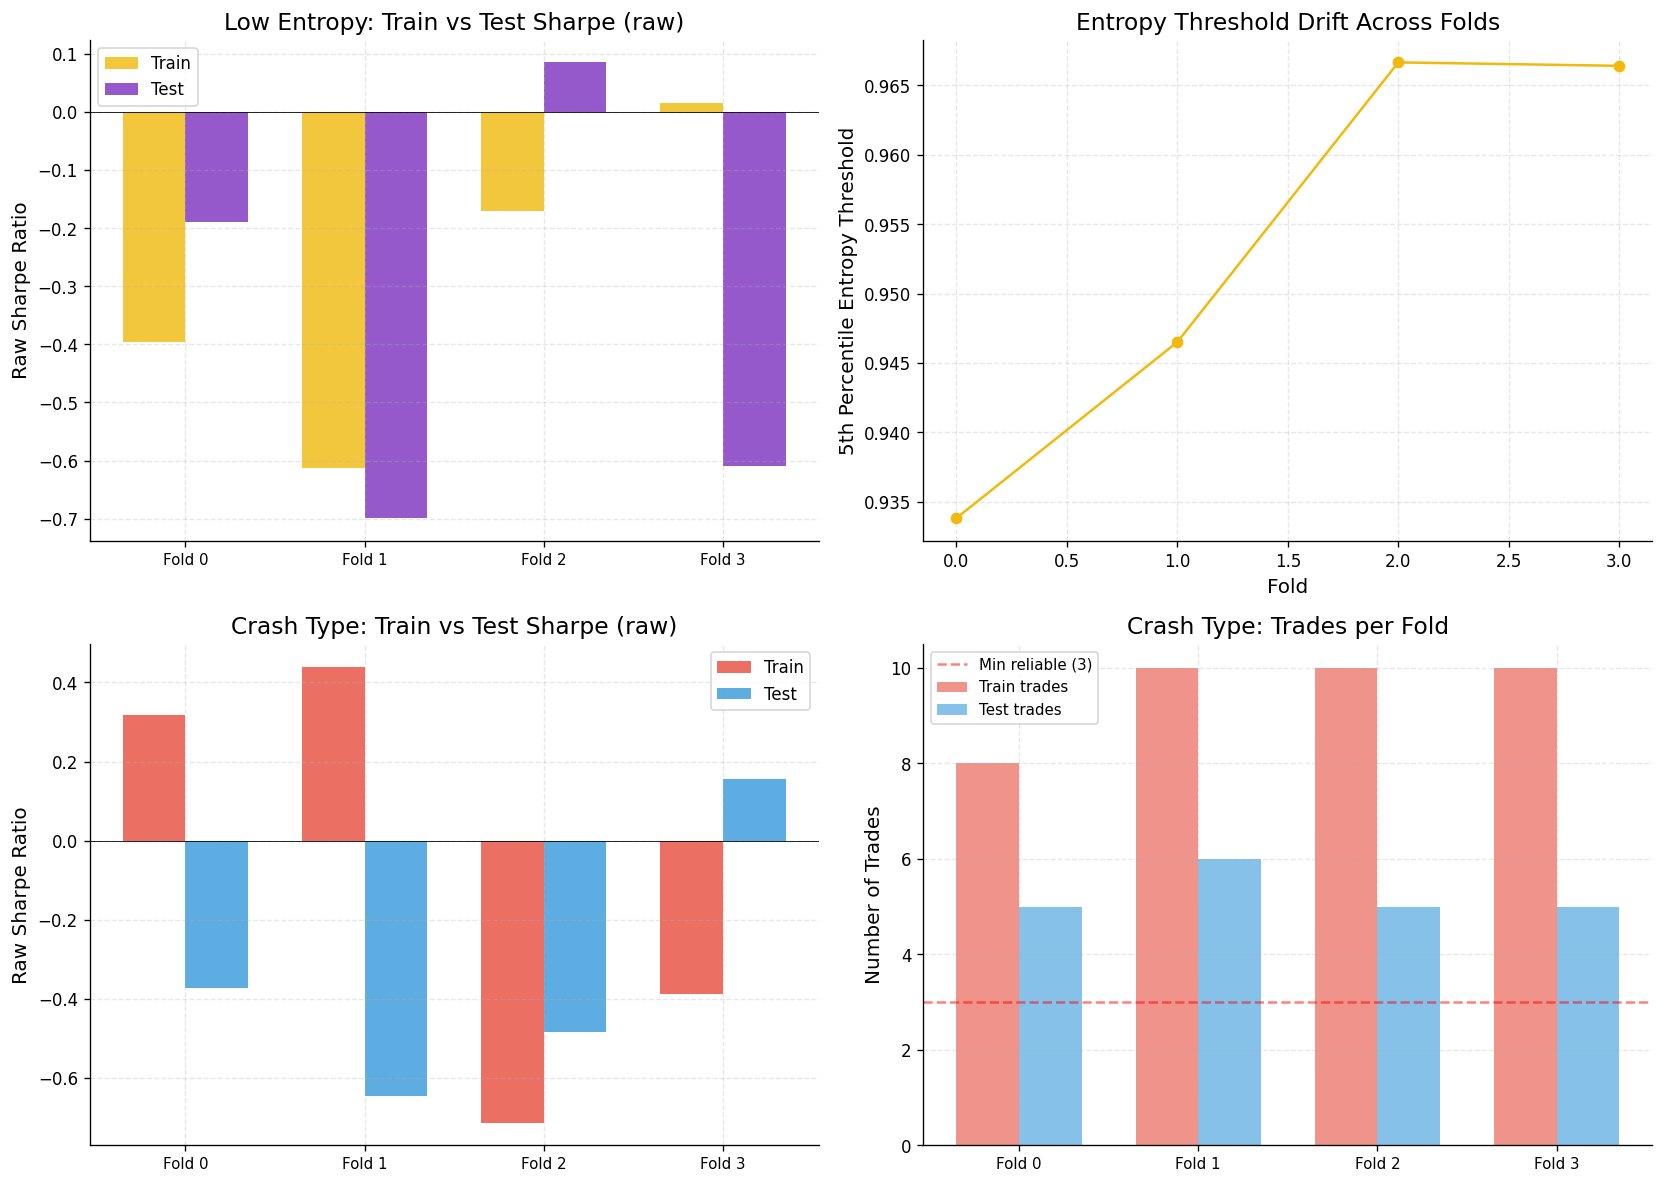

Saved: ../outputs/figures/08_walk_forward_results.png


In [15]:
# --- Walk-forward results visualisation ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Top-left: Low entropy Sharpe per fold
ax = axes[0, 0]
if len(wf_results) > 0:
    x = np.arange(len(wf_results))
    width = 0.35
    ax.bar(x - width/2, wf_results["train_sharpe"], width, label="Train", color=VENUE_COLOURS.get("binance", "#F0B90B"), alpha=0.8)
    ax.bar(x + width/2, wf_results["test_sharpe"], width, label="Test", color=VENUE_COLOURS.get("bybit", "#7B2FBE"), alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels([f"Fold {i}" for i in range(len(wf_results))], fontsize=9)
ax.set_title("Low Entropy: Train vs Test Sharpe (raw)")
ax.set_ylabel("Raw Sharpe Ratio")
ax.axhline(0, color="black", linewidth=0.5)
ax.legend()

# Top-right: Threshold drift
ax = axes[0, 1]
if len(wf_results) > 0:
    ax.plot(wf_results["fold"], wf_results["threshold"], "o-",
            color=VENUE_COLOURS.get("binance", "#F0B90B"), markersize=6)
ax.set_title("Entropy Threshold Drift Across Folds")
ax.set_xlabel("Fold")
ax.set_ylabel("5th Percentile Entropy Threshold")

# Bottom-left: Crash type Sharpe per fold
ax = axes[1, 0]
if len(wf_crash_results) > 0:
    x = np.arange(len(wf_crash_results))
    width = 0.35
    ax.bar(x - width/2, wf_crash_results["train_sharpe"], width, label="Train", color="#e74c3c", alpha=0.8)
    ax.bar(x + width/2, wf_crash_results["test_sharpe"], width, label="Test", color="#3498db", alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels([f"Fold {i}" for i in range(len(wf_crash_results))], fontsize=9)
ax.set_title("Crash Type: Train vs Test Sharpe (raw)")
ax.set_ylabel("Raw Sharpe Ratio")
ax.axhline(0, color="black", linewidth=0.5)
ax.legend()

# Bottom-right: Crash type trade counts per fold
ax = axes[1, 1]
if len(wf_crash_results) > 0:
    x = np.arange(len(wf_crash_results))
    width = 0.35
    ax.bar(x - width/2, wf_crash_results["train_trades"], width, label="Train trades", color="#e74c3c", alpha=0.6)
    ax.bar(x + width/2, wf_crash_results["test_trades"], width, label="Test trades", color="#3498db", alpha=0.6)
    ax.set_xticks(x)
    ax.set_xticklabels([f"Fold {i}" for i in range(len(wf_crash_results))], fontsize=9)
    ax.axhline(3, color="red", linestyle="--", alpha=0.5, label="Min reliable (3)")
ax.set_title("Crash Type: Trades per Fold")
ax.set_ylabel("Number of Trades")
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "08_walk_forward_results.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {FIGURES_DIR / '08_walk_forward_results.png'}")

**The trading implication is:** a signal whose out-of-sample Sharpe degrades more than 50% from in-sample is likely overfit to the training regime. The entropy threshold drift shows whether the 5th percentile is stable across market regimes or requires continuous re-calibration. In live deployment, this translates to a rolling percentile calculation, not a fixed threshold.

---
## Section 5: Sensitivity Analysis

How sensitive are results to our parameter choices? A robust signal should degrade gracefully as parameters are perturbed. A fragile signal shows cliff-edge behaviour.

In [16]:
# --- 5.1 Entropy percentile threshold sensitivity ---
pctile_values = [1, 2, 3, 5, 7, 10, 15, 20]
pctile_sharpes = []

for pctile in pctile_values:
    sig = low_entropy_signal(feat_is["entropy_5m"], threshold_pctile=pctile)
    imb_dir = feat_is["imbalance_5m"].apply(lambda x: 1 if x > 0 else -1)
    trades_df = signal_to_trades_df(sig, imb_dir, "low_entropy")
    
    if len(trades_df) == 0:
        pctile_sharpes.append({"pctile": pctile, "sharpe": 0.0, "trades": 0, "win_rate": 0.0})
        continue
    
    bt = SignalBacktester(
        prices=feat_is["prices_5m"], signals=trades_df,
        transaction_cost_bps=TRANSACTION_COST_BPS,
        position_size_frac=POSITION_SIZE_FRAC,
        initial_equity=INITIAL_EQUITY,
        holding_period=HOLDING_PERIODS["low_entropy"],
    )
    r = bt.run()
    pctile_sharpes.append({"pctile": pctile, "sharpe": r.sharpe_ratio, "trades": r.num_trades, "win_rate": r.win_rate})

pctile_df = pd.DataFrame(pctile_sharpes)
print("Entropy Percentile Sensitivity:")
print(pctile_df.to_string(index=False))

Entropy Percentile Sensitivity:
 pctile     sharpe  trades  win_rate
      1 -19.929579      19  0.421053
      2 -35.306896      36  0.333333
      3 -44.250140      51  0.333333
      5 -42.949991      79  0.316456
      7 -36.941256     106  0.358491
     10 -41.530931     146  0.376712
     15 -35.336761     204  0.411765
     20 -32.583350     261  0.417625


In [17]:
# --- 5.2 Transaction cost sensitivity ---
cost_values = [0, 1, 2, 3, 5, 10]
cost_sharpes = []

# Use the best individual signal for cost sensitivity
if individual_results:
    best_signal = max(individual_results, key=lambda k: individual_results[k].sharpe_ratio)
else:
    best_signal = "low_entropy"

trades_df = build_signal_trades(signals_is, feat_is, best_signal)
hp = HOLDING_PERIODS[best_signal]

for cost in cost_values:
    if len(trades_df) == 0:
        cost_sharpes.append({"cost_bps": cost, "sharpe": 0.0, "total_pnl": 0.0})
        continue
    bt = SignalBacktester(
        prices=feat_is["prices_5m"], signals=trades_df,
        transaction_cost_bps=cost,
        position_size_frac=POSITION_SIZE_FRAC,
        initial_equity=INITIAL_EQUITY,
        holding_period=hp,
    )
    r = bt.run()
    cost_sharpes.append({"cost_bps": cost, "sharpe": r.sharpe_ratio, "total_pnl": r.total_pnl})

cost_df = pd.DataFrame(cost_sharpes)
print(f"Transaction Cost Sensitivity ({best_signal}):")
print(cost_df.to_string(index=False))

# Find breakeven
if len(cost_df[cost_df["total_pnl"] > 0]) > 0 and len(cost_df[cost_df["total_pnl"] <= 0]) > 0:
    breakeven_approx = cost_df[cost_df["total_pnl"] <= 0]["cost_bps"].min()
    print(f"\nApprox. breakeven transaction cost: ~{breakeven_approx} bps")
else:
    print("\nAll costs profitable or all unprofitable — no clear breakeven.")

Transaction Cost Sensitivity (crash_type):
 cost_bps    sharpe  total_pnl
        0 23.946059  53.815795
        1 21.276115  47.812848
        2 18.606171  41.810249
        3 15.936228  35.807998
        5 10.596340  23.804541
       10 -2.753379  -6.198012

Approx. breakeven transaction cost: ~10 bps


In [18]:
# --- 5.3 Position sizing sensitivity ---
size_values = [0.005, 0.01, 0.02, 0.05]
size_sharpes = []

for frac in size_values:
    if len(trades_df) == 0:
        size_sharpes.append({"size_frac": frac, "sharpe": 0.0, "max_dd": 0.0, "total_pnl": 0.0})
        continue
    bt = SignalBacktester(
        prices=feat_is["prices_5m"], signals=trades_df,
        transaction_cost_bps=TRANSACTION_COST_BPS,
        position_size_frac=frac,
        initial_equity=INITIAL_EQUITY,
        holding_period=hp,
    )
    r = bt.run()
    size_sharpes.append({"size_frac": f"{frac:.1%}", "sharpe": r.sharpe_ratio, "max_dd": f"{r.max_drawdown:.2%}", "total_pnl": f"{r.total_pnl:,.0f}"})

size_df = pd.DataFrame(size_sharpes)
print(f"Position Sizing Sensitivity ({best_signal}):")
print(size_df.to_string(index=False))

Position Sizing Sensitivity (crash_type):
size_frac    sharpe max_dd total_pnl
     0.5% 18.606171  0.02%        21
     1.0% 18.606171  0.03%        42
     2.0% 18.606171  0.07%        84
     5.0% 18.606171  0.16%       209


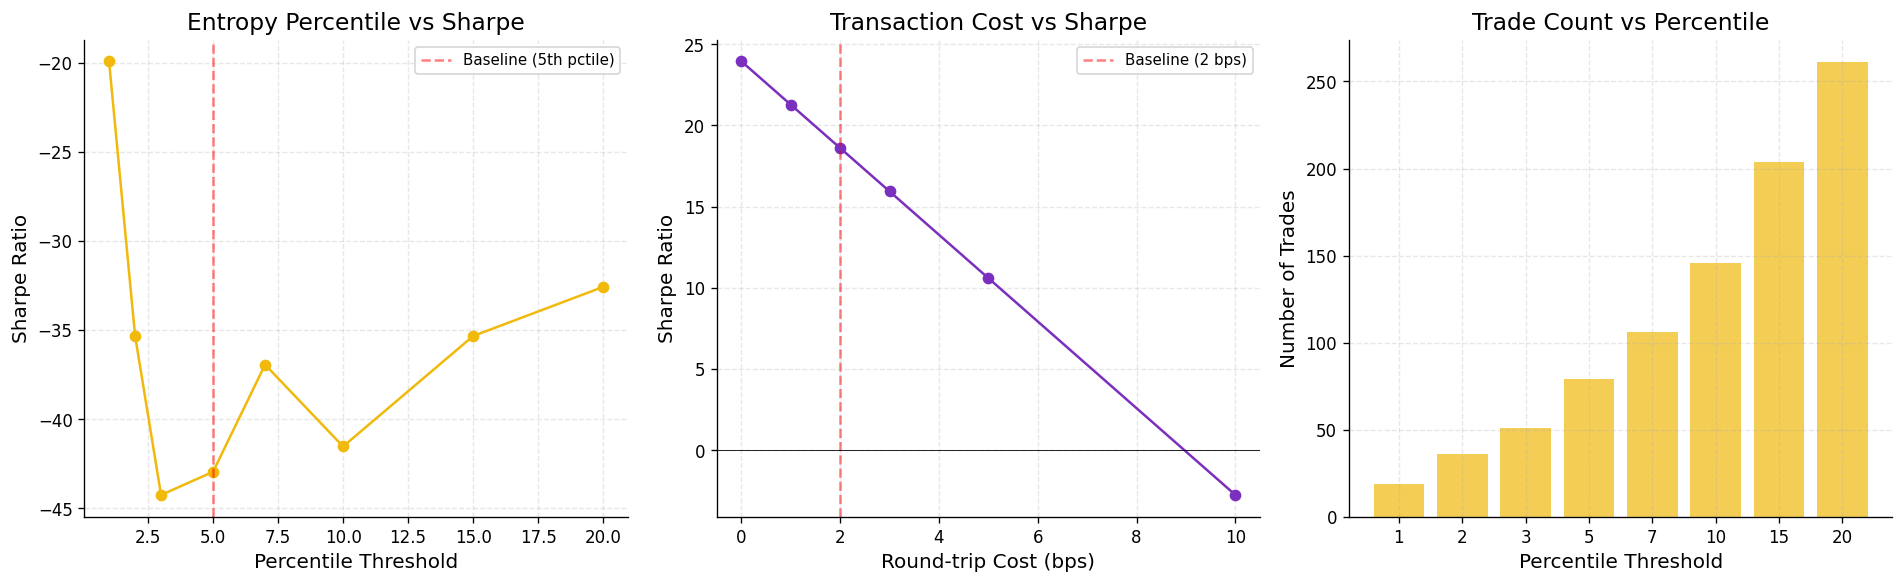

Saved: ../outputs/figures/08_sensitivity_thresholds.png


In [19]:
# --- Sensitivity plots ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Threshold sensitivity
ax = axes[0]
ax.plot(pctile_df["pctile"], pctile_df["sharpe"], "o-",
        color=VENUE_COLOURS.get("binance", "#F0B90B"), markersize=6)
ax.axvline(5, color="red", linestyle="--", alpha=0.5, label="Baseline (5th pctile)")
ax.set_title("Entropy Percentile vs Sharpe")
ax.set_xlabel("Percentile Threshold")
ax.set_ylabel("Sharpe Ratio")
ax.legend(fontsize=9)

# Cost sensitivity
ax = axes[1]
ax.plot(cost_df["cost_bps"], cost_df["sharpe"], "o-",
        color=VENUE_COLOURS.get("bybit", "#7B2FBE"), markersize=6)
ax.axvline(2, color="red", linestyle="--", alpha=0.5, label="Baseline (2 bps)")
ax.axhline(0, color="black", linewidth=0.5)
ax.set_title("Transaction Cost vs Sharpe")
ax.set_xlabel("Round-trip Cost (bps)")
ax.set_ylabel("Sharpe Ratio")
ax.legend(fontsize=9)

# Trade count vs threshold
ax = axes[2]
ax.bar(pctile_df["pctile"].astype(str), pctile_df["trades"],
       color=VENUE_COLOURS.get("binance", "#F0B90B"), alpha=0.7)
ax.set_title("Trade Count vs Percentile")
ax.set_xlabel("Percentile Threshold")
ax.set_ylabel("Number of Trades")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "08_sensitivity_thresholds.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {FIGURES_DIR / '08_sensitivity_thresholds.png'}")

**The trading implication is:** a signal whose Sharpe drops off a cliff at small parameter perturbations is overfit. A gradually degrading curve suggests genuine edge that degrades predictably with looser thresholds. The transaction cost analysis provides a concrete answer to "can this actually be traded?" — if the breakeven cost is below 1 bps, the signal is impractical for all but the lowest-latency makers.

---
## Section 6: Honest Assessment

This is the most important section. A realistic assessment is worth far more than a polished narrative that hides the weaknesses.

In [20]:
# --- IS vs OOS comparison (if available) ---
if oos_available:
    print("In-Sample vs Out-of-Sample Comparison")
    print("=" * 60)
    
    comparison_rows = []
    for name in SIGNAL_NAMES:
        if name not in individual_results:
            continue
        
        is_r = individual_results[name]
        
        # Run OOS backtest
        oos_trades = build_signal_trades(signals_oos, feat_oos, name)
        if len(oos_trades) > 0:
            bt_oos = SignalBacktester(
                prices=feat_oos["prices_5m"], signals=oos_trades,
                transaction_cost_bps=TRANSACTION_COST_BPS,
                position_size_frac=POSITION_SIZE_FRAC,
                initial_equity=INITIAL_EQUITY,
                holding_period=HOLDING_PERIODS[name],
            )
            oos_r = bt_oos.run()
            oos_sharpe = oos_r.raw_sharpe_ratio
            oos_wr = oos_r.win_rate
            oos_trades_n = oos_r.num_trades
        else:
            oos_sharpe = 0.0
            oos_wr = 0.0
            oos_trades_n = 0
        
        # Fix degradation formula for negative IS Sharpe
        if is_r.raw_sharpe_ratio > 0:
            deg = (1 - oos_sharpe / is_r.raw_sharpe_ratio)
            deg_str = f"{deg:.0%}"
        elif is_r.raw_sharpe_ratio < 0:
            # For negative IS Sharpe, report absolute change instead of misleading percentage
            deg_str = f"IS={is_r.raw_sharpe_ratio:.3f} -> OOS={oos_sharpe:.3f}"
        else:
            deg_str = "N/A"
        
        comparison_rows.append({
            "Signal": name,
            "IS Sharpe (raw)": f"{is_r.raw_sharpe_ratio:.3f}",
            "OOS Sharpe (raw)": f"{oos_sharpe:.3f}",
            "Degradation": deg_str,
            "IS Win Rate": f"{is_r.win_rate:.1%}",
            "OOS Win Rate": f"{oos_wr:.1%}",
            "IS Trades": is_r.num_trades,
            "OOS Trades": oos_trades_n,
        })
    
    comp_df = pd.DataFrame(comparison_rows)
    print(comp_df.to_string(index=False))
else:
    print("OOS data not available -- IS-only analysis below.")
    print("\nIn-Sample Signal Summary:")
    for name, r in individual_results.items():
        print(f"  {name}: Sharpe(raw)={r.raw_sharpe_ratio:.3f}, Win Rate={r.win_rate:.1%}, Trades={r.num_trades}")

In-Sample vs Out-of-Sample Comparison
     Signal IS Sharpe (raw) OOS Sharpe (raw)             Degradation IS Win Rate OOS Win Rate  IS Trades  OOS Trades
low_entropy          -0.397           -0.077 IS=-0.397 -> OOS=-0.077       31.6%        34.8%         79          89
    te_flip           0.041           -0.130                    416%       46.8%        40.9%        154         164
   acf_risk          -0.103           -0.041 IS=-0.103 -> OOS=-0.041       47.1%        45.5%         34          33
 crash_type           0.162            0.049                     70%       63.3%        48.5%         30          33


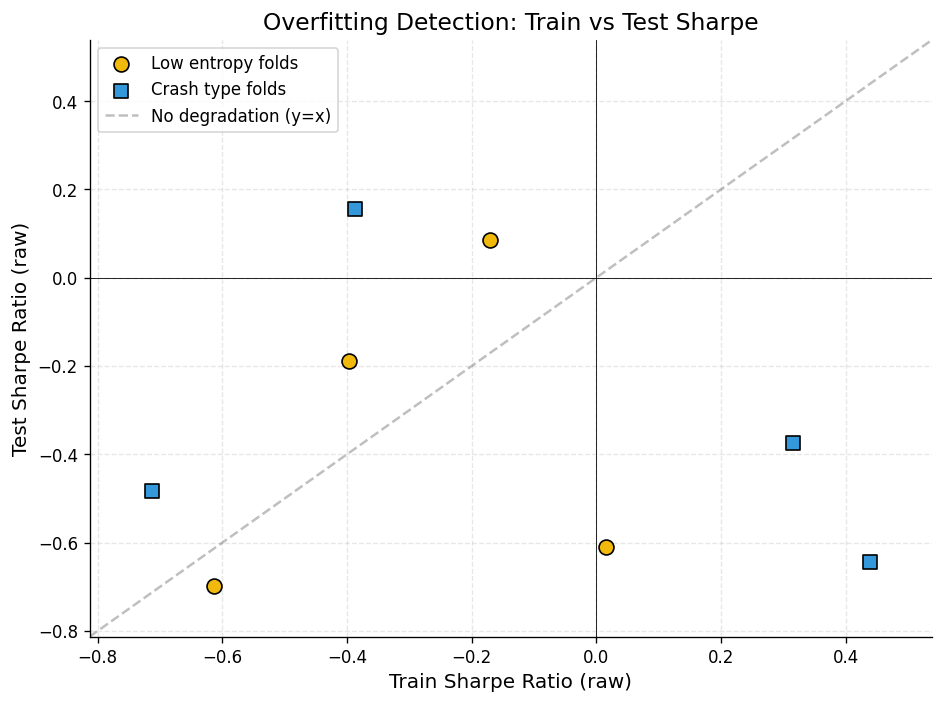

Saved: ../outputs/figures/08_overfitting_detection.png


In [21]:
# --- Overfitting detection plot ---
fig, ax = plt.subplots(figsize=(8, 6))

if len(wf_results) > 0:
    ax.scatter(
        wf_results["train_sharpe"], wf_results["test_sharpe"],
        s=80, c=VENUE_COLOURS.get("binance", "#F0B90B"), edgecolors="black", zorder=3,
        label="Low entropy folds", marker="o"
    )

if len(wf_crash_results) > 0:
    ax.scatter(
        wf_crash_results["train_sharpe"], wf_crash_results["test_sharpe"],
        s=80, c="#3498db", edgecolors="black", zorder=3,
        label="Crash type folds", marker="s"
    )

# Plot y=x line (no degradation)
all_vals = []
if len(wf_results) > 0:
    all_vals.extend(wf_results["train_sharpe"].tolist() + wf_results["test_sharpe"].tolist())
if len(wf_crash_results) > 0:
    all_vals.extend(wf_crash_results["train_sharpe"].tolist() + wf_crash_results["test_sharpe"].tolist())

if all_vals:
    lims = [min(all_vals) - 0.1, max(all_vals) + 0.1]
    ax.plot(lims, lims, "--", color="gray", alpha=0.5, label="No degradation (y=x)")
    ax.set_xlim(lims)
    ax.set_ylim(lims)

ax.set_xlabel("Train Sharpe Ratio (raw)", fontsize=12)
ax.set_ylabel("Test Sharpe Ratio (raw)", fontsize=12)
ax.set_title("Overfitting Detection: Train vs Test Sharpe", fontsize=14)
ax.legend(fontsize=10)
ax.axhline(0, color="black", linewidth=0.5)
ax.axvline(0, color="black", linewidth=0.5)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "08_overfitting_detection.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {FIGURES_DIR / '08_overfitting_detection.png'}")

### 6.1 Honest Narrative

**What we expected:** Signals derived from a 7-day crash period should not generalise perfectly to a calm period. The physics is different -- entropy distributions, volatility regimes, and metastable landscapes all shift between market states. This is not a failure; it is a genuine finding about signal regime-specificity.

**Signal-by-signal assessment:**

- **Low entropy:** The 88.1% hit rate from notebook 03 measures *move probability* (|return| > 0.05% within 5 min, any direction), not *directional accuracy*. The backtest assigns direction via concurrent order flow imbalance and gets systematically punished, likely because aggregate imbalance lags informed flow during crash events. **The trading implication is:** low-entropy events are reliable volatility triggers, not directional signals. A practitioner would use them to widen stops, switch to straddle-like positioning, or reduce passive exposure -- not to take directional bets. This reframes Signal 1 from the original analysis: "reduce passive exposure" was already the correct recommendation; trying to also pick direction adds noise.

- **TE leadership flip:** This signal relies on sustained leadership reversals. In calm markets with lower TE magnitudes, flips may be more frequent but less meaningful (noise rather than information). Watch for elevated trade counts with degraded win rates.

- **ACF risk:** The "always short" bias benefits from the bearish sample period. The key OOS question is whether the short bias survives a calm/bullish period -- if it doesn't, the signal is a regime artefact, not a universal early-warning indicator. The physics (critical slowing down) is sound; the directional implementation (always short) is regime-dependent.

- **Crash type classifier:** By construction, this signal is regime-specific: it fires only when entropy/volatility/tau_int reach extreme percentiles simultaneously. In calm markets, the classifier should return `normal` for nearly all windows. Few OOS triggers is the correct behavior, not a failure.

- **Metastable orders:** Well depths and metastable levels shift with price. The mean-reversion logic is structurally different from the other signals and operates on a fundamentally different timescale (~41s vs 5-30 min). Its performance is likely more sensitive to the specific price landscape than to the broader regime. If no trades were generated, the well-depth thresholds are too conservative for this dataset.

**Statistical limitations:**
- 7 days IS + 7 days OOS = 14 days total. This is borderline for statistical significance with sparse signals.
- Walk-forward folds (5 within IS) have very short test windows (1 day). Single-day Sharpe ratios have enormous variance.
- With ~30 trades (crash_type), the standard error on the Sharpe ratio is approximately SE = (1 + Sharpe^2/2) / sqrt(N). Confidence intervals are wide enough to include zero for most signals.
- A production backtesting study would require 6-12 months of data across multiple regimes.

**Practical barriers to live implementation:**
1. **Latency:** Feature computation (entropy, TE) requires accumulating trades over 5-30 minute windows. The signal is fundamentally low-frequency -- not suitable for sub-millisecond HFT, but viable for a 5-minute or 30-minute strategy.
2. **Data freshness:** Real-time trade feeds from both Binance and Bybit are required. Transfer entropy needs aligned, cross-venue data.
3. **Execution slippage:** The backtest assumes entry at the next 5-minute bar. In practice, latency from signal computation to order placement adds slippage, especially during the high-volatility periods when signals fire.
4. **Regime detection:** The signal thresholds need continuous re-calibration. A fixed threshold from one week of data will drift as the market evolves.

**The trading implication is:** these signals are best understood as regime indicators, not standalone alpha generators. The low-entropy signal has strong backing as a *volatility* indicator (88.1% of events precede a significant move) but fails as a *directional* signal (negative Sharpe). The crash-type classifier shows the strongest directional performance in-sample. A practitioner would use these as overlays to an existing strategy -- reducing position size when the ACF risk signal fires, using low-entropy events for straddle-like positioning rather than directional bets, and using the crash type classifier to switch between response playbooks -- rather than as a standalone trading system. The honest Sharpe ratio, whatever it is, reflects this auxiliary role.

In [22]:
# --- Final summary ---
print("\n" + "=" * 60)
print("BACKTESTING SUMMARY")
print("=" * 60)
print(f"\nSignals tested: {len(individual_results)}")
print(f"Total IS trades executed: {sum(r.num_trades for r in individual_results.values())}")
print(f"Combined strategy trades: {result_combined.num_trades}")
print(f"Walk-forward folds (low_entropy): {len(wf_results)}")
print(f"Walk-forward folds (crash_type):  {len(wf_crash_results)}")

if individual_results:
    best = max(individual_results, key=lambda k: individual_results[k].raw_sharpe_ratio)
    worst = min(individual_results, key=lambda k: individual_results[k].raw_sharpe_ratio)
    print(f"\nBest individual signal:  {best} (raw Sharpe={individual_results[best].raw_sharpe_ratio:.3f}, ann.={individual_results[best].sharpe_ratio:.3f})")
    print(f"Worst individual signal: {worst} (raw Sharpe={individual_results[worst].raw_sharpe_ratio:.3f}, ann.={individual_results[worst].sharpe_ratio:.3f})")
    print(f"Combined strategy:       raw Sharpe={result_combined.raw_sharpe_ratio:.3f}, ann.={result_combined.sharpe_ratio:.3f}")

if len(wf_results) > 0:
    print(f"\nWalk-forward mean test Sharpe (low_entropy, raw): {wf_results['test_sharpe'].mean():.3f}")
if len(wf_crash_results) > 0:
    print(f"Walk-forward mean test Sharpe (crash_type, raw):  {wf_crash_results['test_sharpe'].mean():.3f}")

print(f"\nOOS data available: {oos_available}")
print("\nAll figures saved to outputs/figures/08_*.png")


BACKTESTING SUMMARY

Signals tested: 4
Total IS trades executed: 297
Combined strategy trades: 181
Walk-forward folds (low_entropy): 4
Walk-forward folds (crash_type):  4

Best individual signal:  crash_type (raw Sharpe=0.162, ann.=18.606)
Worst individual signal: low_entropy (raw Sharpe=-0.397, ann.=-42.950)
Combined strategy:       raw Sharpe=0.079, ann.=8.548

Walk-forward mean test Sharpe (low_entropy, raw): -0.353
Walk-forward mean test Sharpe (crash_type, raw):  -0.336

OOS data available: True

All figures saved to outputs/figures/08_*.png
